# Добавим необходимые библиотеки для первичной обработки данных 

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [58]:
df = pd.read_csv('../data/raw.csv')
df 

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [59]:
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [60]:
df.duplicated().sum()

np.int64(1)

In [61]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [62]:
df.info()

<class 'pandas.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   str    
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   str    
 5   region    1337 non-null   str    
 6   charges   1337 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 83.6 KB


In [63]:
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


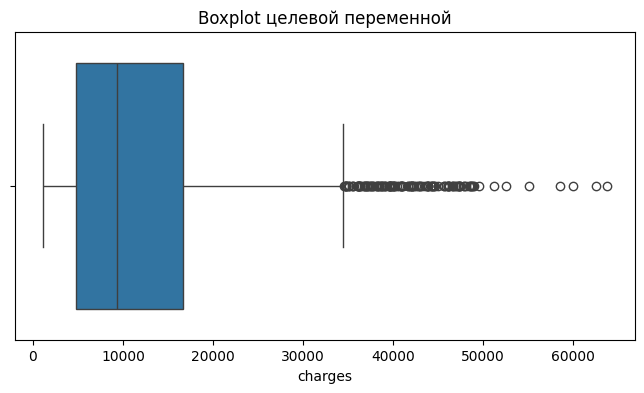

In [64]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df["charges"])
plt.title("Boxplot целевой переменной")
plt.xlabel("charges")
plt.show()

По графику boxplot видно, что у целевой переменной присутствуют выбросы.  
Но нельзя пока говорить, что это аномалии, нужно проверить данные.

In [65]:
df[df["charges"] > 35000]

,age,sex,bmi,children,smoker,region,charges
14,27,male,42.130,0,yes,southeast,39611.75770
19,30,male,35.300,0,yes,southwest,36837.46700
23,34,female,31.920,1,yes,northeast,37701.87680
29,31,male,36.300,2,yes,southwest,38711.00000
30,22,male,35.600,0,yes,southwest,35585.57600
...,...,...,...,...,...,...,...
1300,45,male,30.360,0,yes,southeast,62592.87309
1301,62,male,30.875,3,yes,northwest,46718.16325
1303,43,male,27.800,0,yes,southwest,37829.72420
1313,19,female,34.700,2,yes,southwest,36397.57600


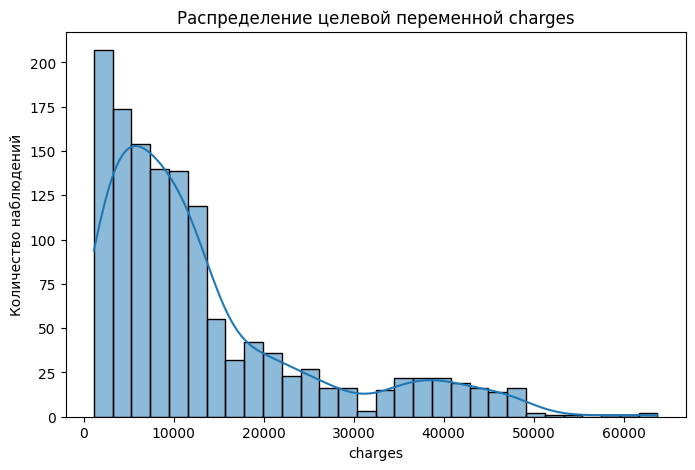

In [66]:
plt.figure(figsize=(8, 5))
sns.histplot(df["charges"], kde=True, bins=30)
plt.title("Распределение целевой переменной charges")
plt.xlabel("charges")
plt.ylabel("Количество наблюдений")
plt.show()

Видим, что распределение целевой имеет правиостороннюю ассиметрию. Основная часть значений меньше 20000.

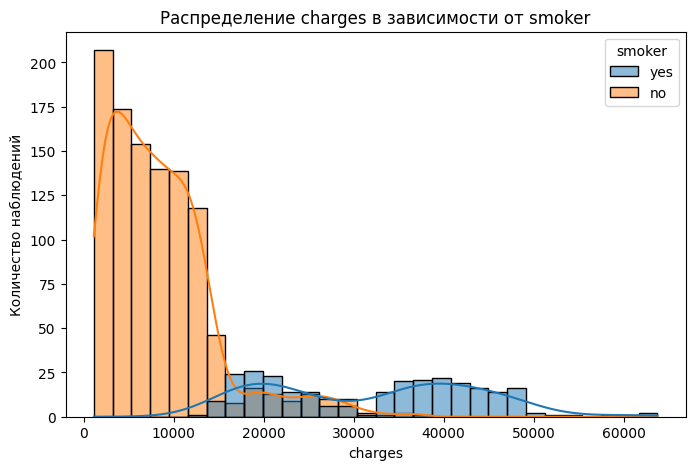

In [67]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="charges", hue="smoker", kde=True, bins=30)
plt.title("Распределение charges в зависимости от smoker")
plt.xlabel("charges")
plt.ylabel("Количество наблюдений")
plt.show()

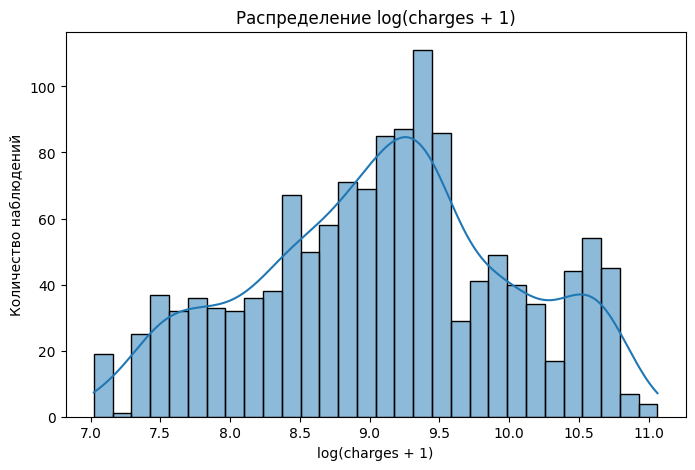

In [68]:
plt.figure(figsize=(8, 5))
sns.histplot(np.log1p(df["charges"]), kde=True, bins=30)
plt.title("Распределение log(charges + 1)")
plt.xlabel("log(charges + 1)")
plt.ylabel("Количество наблюдений")
plt.show()

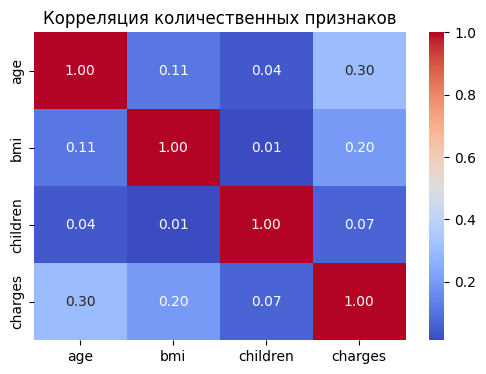

In [69]:
numeric_cols_for_corr = ['age', 'bmi', 'children', 'charges']
corr = df[numeric_cols_for_corr].corr()
plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляция количественных признаков')
plt.show()

## Корреляционная матрица после логарифмирования таргета

Теперь заменим исходный таргет на `log1p(charges)` и снова посмотрим корреляции только между количественными признаками. Логарифмирование уменьшает правостороннюю асимметрию целевой переменной и может сделать связи с числовыми признаками более заметными.


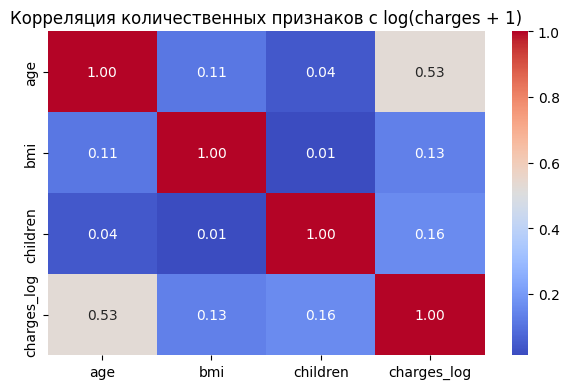

charges_log    1.000000
age            0.526900
children       0.160316
bmi            0.132831
Name: charges_log, dtype: float64

In [70]:
from pathlib import Path

df_corr_log = df.copy()
df_corr_log['charges_log'] = np.log1p(df_corr_log['charges'])

numeric_cols_for_corr_log = ['age', 'bmi', 'children', 'charges_log']
corr_log = df_corr_log[numeric_cols_for_corr_log].corr()

figures_dir = Path('../reports/figures')
figures_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(6, 4))
sns.heatmap(corr_log, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляция количественных признаков с log(charges + 1)')
plt.tight_layout()
plt.savefig(figures_dir / 'correlation_matrix_numeric_log_target.png', dpi=200, bbox_inches='tight')
plt.show()

corr_log['charges_log'].sort_values(ascending=False)


по матрице корреляции признаков мы видим, что есть одна сильная корреляция между целевой переменной и курением. Но также нельзя сбрасывать cо счетов region-bmi, target-bmi, age-target.

## Стратифицированное разделение данных

Для задачи регрессии целевая переменная `charges` непрерывная, поэтому напрямую использовать `stratify=y` нельзя. Сначала разобьем `charges` на интервалы, а затем совместим эти интервалы с признаком `smoker`, потому что курение сильнее всего связано со стоимостью страховки.

In [71]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['charges'])
y = np.log1p(df['charges'])
y_original = df['charges']

charge_bins = pd.qcut(y_original, q=5, labels=False, duplicates='drop')
strata = df['smoker'].astype(str) + '_' + charge_bins.astype(str)

X_train_val, X_test, y_train_val, y_test, y_train_val_original, y_test_original, strata_train_val, strata_test = train_test_split(
    X,
    y,
    y_original,
    strata,
    test_size=0.2,
    random_state=42,
    stratify=strata
)

X_train, X_val, y_train, y_val, y_train_original, y_val_original = train_test_split(
    X_train_val,
    y_train_val,
    y_train_val_original,
    test_size=0.25,
    random_state=42,
    stratify=strata_train_val
)

print('X_train shape:', X_train.shape)
print('X_val shape:', X_val.shape)
print('X_test shape:', X_test.shape)
print('y_train_log shape:', y_train.shape)
print('y_val_log shape:', y_val.shape)
print('y_test_log shape:', y_test.shape)

X_train shape: (801, 6)
X_val shape: (268, 6)
X_test shape: (268, 6)
y_train_log shape: (801,)
y_val_log shape: (268,)
y_test_log shape: (268,)


In [72]:
print('Доля smoker в train:')
print(X_train['smoker'].value_counts(normalize=True))

print('\nДоля smoker в test:')
print(X_test['smoker'].value_counts(normalize=True))

print('\nДоля smoker в validation:')
print(X_val['smoker'].value_counts(normalize=True))

print('\nОписание charges в train:')
print(y_train.describe())

print('\nОписание charges в test:')
print(y_test.describe())

print('\nОписание charges в validation:')
print(y_val.describe())

Доля smoker в train:
smoker
no     0.795256
yes    0.204744
Name: proportion, dtype: float64

Доля smoker в test:
smoker
no     0.794776
yes    0.205224
Name: proportion, dtype: float64

Доля smoker в validation:
smoker
no     0.794776
yes    0.205224
Name: proportion, dtype: float64

Описание charges в train:
count    801.000000
mean       9.106437
std        0.923000
min        7.023647
25%        8.459395
50%        9.152068
75%        9.743574
max       11.044423
Name: charges, dtype: float64

Описание charges в test:
count    268.000000
mean       9.080500
std        0.907025
min        7.036096
25%        8.498985
50%        9.099336
75%        9.668953
max       10.978013
Name: charges, dtype: float64

Описание charges в validation:
count    268.000000
mean       9.100744
std        0.919807
min        7.036500
25%        8.462238
50%        9.168751
75%        9.650825
max       11.063061
Name: charges, dtype: float64


## OneHotEncoding после разделения

Кодировщик обучается только на `X_train`, затем применяется к `X_val` и `X_test`. Таргет сохраняется как `log1p(charges)`, а исходное значение хранится в `charges_original`, чтобы считать метрики в реальной шкале.

In [73]:
from sklearn.preprocessing import OneHotEncoder

categorical_cols = ['sex', 'smoker', 'region']
numeric_cols = ['age', 'bmi', 'children']

encoder = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
encoder.fit(X_train[categorical_cols])

encoded_cols = encoder.get_feature_names_out(categorical_cols)

def make_one_hot_frame(X_part):
    encoded = pd.DataFrame(
        encoder.transform(X_part[categorical_cols]),
        columns=encoded_cols,
        index=X_part.index
    )
    return pd.concat([X_part[numeric_cols], encoded], axis=1)

X_train_encoded = make_one_hot_frame(X_train)
X_val_encoded = make_one_hot_frame(X_val)
X_test_encoded = make_one_hot_frame(X_test)

X_train_encoded.head()

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
446,60,29.64,0,1.0,0.0,0.0,0.0,0.0
256,56,33.63,0,1.0,1.0,1.0,0.0,0.0
881,23,27.36,1,1.0,0.0,1.0,0.0,0.0
22,18,34.10,0,1.0,0.0,0.0,1.0,0.0
608,28,26.98,2,1.0,0.0,0.0,0.0,0.0


## Сохранение train/validation/test выборок

Сохраним уже разделенные и закодированные данные, чтобы дальше использовать их в ноутбуках с моделями.

In [74]:
from pathlib import Path

train_one_hot_encoded = X_train_encoded.copy()
train_one_hot_encoded['charges'] = y_train
train_one_hot_encoded['charges_original'] = y_train_original

validation_one_hot_encoded = X_val_encoded.copy()
validation_one_hot_encoded['charges'] = y_val
validation_one_hot_encoded['charges_original'] = y_val_original

test_one_hot_encoded = X_test_encoded.copy()
test_one_hot_encoded['charges'] = y_test
test_one_hot_encoded['charges_original'] = y_test_original

processed_dir = Path('../data/processed')
processed_dir.mkdir(parents=True, exist_ok=True)

train_one_hot_encoded.to_csv(processed_dir / 'train_one_hot_encoded.csv', index=False)
validation_one_hot_encoded.to_csv(processed_dir / 'validation_one_hot_encoded.csv', index=False)
test_one_hot_encoded.to_csv(processed_dir / 'test_one_hot_encoded.csv', index=False)

train_one_hot_encoded.head()

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest,charges,charges_original
446,60,29.64,0,1.0,0.0,0.0,0.0,0.0,9.451874,12730.9996
256,56,33.63,0,1.0,1.0,1.0,0.0,0.0,10.690175,43921.1837
881,23,27.36,1,1.0,0.0,1.0,0.0,0.0,7.933817,2789.0574
22,18,34.10,0,1.0,0.0,0.0,1.0,0.0,7.037037,1137.0110
608,28,26.98,2,1.0,0.0,0.0,0.0,0.0,8.397530,4435.0942
